# Pleural effusion X-ray Image Classification using Machine Learning 

by Salomon Marquez

22/04/2025

Pleural effusion is a medical condition characterized by an abnormal accumulation of fluid in the chest cavity, which can be identified through diagnostic imaging such as chest X-rays.The goal of this project is to implement and evaluate Convolutional Neural Networks (CNNs) to automatically classify X-ray images into two categories: normal or effusion. 

Using a subset of the public NIH ChestXray14 dataset, the project involves processing 700 radiographies (350 normal and 350 with effusion) to assist in medical diagnosis through deep learning. To achieve accurate classification, the images are preprocessed from their original 512x512x3 dimensions to a 64x64x1 grayscale format and normalized using min-max transformation. The project implements two different CNN architectures, each featuring up to six convolutional layers, pooling layers to reduce parameters, and fully connected layers (128 and 32 nodes) with a sigmoid activation for the final output.

Finally, the performance of the two networks is compared using ROC curves and various quality metrics to determine which architecture provides the most reliable classification results.

Visit the <i class="fa-brands fa-github"></i> [repository of the project](https://github.com/sblaizerwize/My-Professional-Portfolio/tree/main/docs/machine-learning/chest-x-ray-classification-normal-vs-pleural-effusion) to check out:  

- <i class="fas fa-file-csv"></i> `normal.npy` and `effusion.npy` datasets
- <i class="fab fa-google"></i> Colab notebook 

---

## Installing dependencies and configuring the working directory

In [ ]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

from IPython.display import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import roc_curve, roc_auc_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [ ]:
# Set working directory in Gdrive
os.chdir("/content/drive/MyDrive/ASIGNATURAS/M0.163 MACHINE LEARNING/[02 ABR - 29 ABR] RETO 2/PEC2")

In [ ]:
# View working directory contents
!ls

 AlexNet_architecture.png   LeNet-5_architecture.png
'Debate PEC2.gdoc'	    normal
 effusion		    normal.npy
 effusion.zip		    normal.zip
 efussion.npy		    PEC2_Machine_Learning.html
 enunciadoPEC2_2425_2.pdf   PEC2_Machine_Learning.ipynb


---

## Data loading and preprocessing

**NOTE: Go to the `Data Preparation` section if the `normal.npy` and `effusion.npy` files are already created in the working directory.**

In this section we will take a look at the data in the `normal.zip` and `effusion.zip` files. We will examine the most practical way to work with these files either by unzipping them and loading them directly into a variable, given that their size is 110 MB and 105 MB, respectively, or by creating a new dataset.


To give us an idea of ​​the preprocessing that must be done to the data before sending it to the CNN, since the `normal.zip` and `effusion.zip` files contain `.png` images, we are going to review the `CNN_MNIST.ipynb` notebook located in the [Machine Learning Bioinformatics de la UOC](https://gitlab.uoclabs.uoc.es/machinelearningbioinformatics/machine-learning-bioinformatics/-/blob/master/5_NeuralNetworks/CNN_MNIST.ipynb?ref_type=heads) repository. This notebook works with a dataset called MNIST that contains images of digits. The objective is to determine what type of data and size these data have in order to apply the same format to the x-ray images.

In [ ]:
# Example with MNIST dataset
from tensorflow.keras.datasets import mnist

# Load data from the MNIST dataset
(x_train_orig, y_train_orig), (x_test_orig, y_test_orig) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Get the size and type of data
x_train_orig.shape, type(x_train_orig)

((60000, 28, 28), numpy.ndarray)

In [ ]:
# View the first item
x_train_orig[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 170,
        253, 253, 253, 253, 253, 225, 172, 253, 242, 195,  64,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  49, 238, 253, 253, 253, 253,
        253, 253, 253, 253, 251,  93,  82,  82,  56,  39,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  18, 219, 253, 253, 253, 253,
        253, 198, 182, 247, 241,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  80, 156, 107, 253, 253,
        205,  11,   0,  43, 154,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  14,   1, 154, 253,
         90,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 139, 253,
        190,   2,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  11, 190,
        253,  70,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  35,
        241, 225, 160, 108,   1,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         81, 240, 253, 253, 119,  25,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  45, 186, 253, 253, 150,  27,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  16,  93, 252, 253, 187,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0, 249, 253, 249,  64,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  46, 130, 183, 253, 253, 207,   2,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  39,
        148, 229, 253, 253, 253, 250, 182,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  24, 114, 221,
        253, 253, 253, 253, 201,  78,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  23,  66, 213, 253, 253,
        253, 253, 198,  81,   2,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  18, 171, 219, 253, 253, 253, 253,
        195,  80,   9,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  55, 172, 226, 253, 253, 253, 253, 244, 133,
         11,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 136, 253, 25

In conclusion, the images of the digits have the following format `((60000, 28, 28), numpy.ndarray)`, so one would expect that for the images in the files `normal.zip` and `effusion.zip` the final array format would be `((350, 64, 64), numpy.ndarray)`.

Next we will read the data in `normal.zip` and `effusion.zip`.

In [ ]:
# Open the normal.zip file, read images and save to an array
import zipfile
from PIL import Image

imagenes = []
with zipfile.ZipFile("normal.zip") as z:
  for filename in z.namelist():
    if filename.endswith(".png"):     # Read only .png files
      with z.open(filename) as file:
        img       = Image.open(file)  # Open file
        img_array = np.array(img)     # Convert to array type
        imagenes.append(img_array)

# Convert list of image arrays to a single NumPy array
normal_array = np.array(imagenes)

In [ ]:
# View dimensions and data type
normal_array.shape, type(normal_array)

((350, 512, 512, 3), numpy.ndarray)

array([[[227, 227, 227],
        [224, 224, 224],
        [221, 221, 221],
        ...,
        [226, 226, 226],
        [229, 229, 229],
        [199, 199, 199]],

       [[220, 220, 220],
        [215, 215, 215],
        [205, 205, 205],
        ...,
        [218, 218, 218],
        [222, 222, 222],
        [194, 194, 194]],

       [[213, 213, 213],
        [195, 195, 195],
        [170, 170, 170],
        ...,
        [210, 210, 210],
        [214, 214, 214],
        [188, 188, 188]],

       ...,

       [[  8,   8,   8],
        [  8,   8,   8],
        [  7,   7,   7],
        ...,
        [ 39,  39,  39],
        [ 69,  69,  69],
        [ 81,  81,  81]],

       [[  9,   9,   9],
        [  8,   8,   8],
        [  7,   7,   7],
        ...,
        [ 40,  40,  40],
        [ 68,  68,  68],
        [ 80,  80,  80]],

       [[  9,   9,   9],
        [  8,   8,   8],
        [  7,   7,   7],
        ...,
        [ 41,  41,  41],
        [ 71,  71,  71],
        [ 81,  81,  81]]], dtype=uint8)
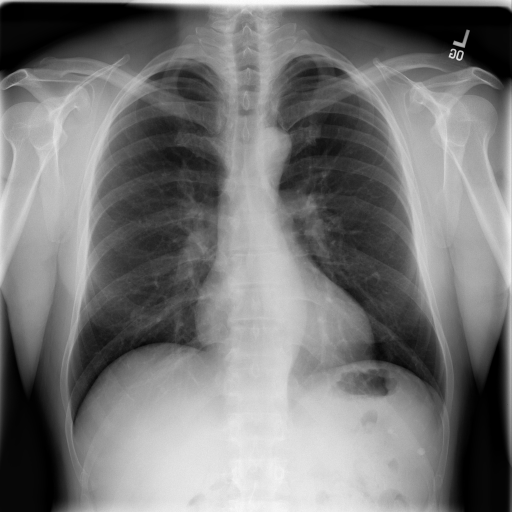

In [ ]:
# View the first item
normal_array[0]

It is possible to convert to grayscale and resize images when reading them using the `convert("L")` and `resize((64, 64))` methods of the `Image` [Pillow](https://pillow.readthedocs.io/en/stable/) library. Let's see

In [ ]:
# Convert the image to grayscale and resize it from reading the files
imagenes = []
with zipfile.ZipFile("normal.zip") as z:
  for filename in z.namelist():
    if filename.endswith(".png"):
      with z.open(filename) as file:
        img_gray  = Image.open(file).convert("L")  # Transform the image to grayscale
        img_64_64 = img_gray.resize((64, 64))      # Resize to 64 x 64
        img_array = np.array(img_64_64)
        imagenes.append(img_array)

# Convert list of image arrays to a single NumPy array
normal_array = np.array(imagenes)

In [ ]:
# View dimensions and data type
normal_array.shape, type(normal_array)

((350, 64, 64), numpy.ndarray)

array([[ 88,  43,  37, ..., 126, 138, 173],
       [  0,   0,   0, ...,   1,   3,  25],
       [  3,   2,   2, ...,   0,   0,   0],
       ...,
       [  7,   7,   7, ...,   5,   3,  21],
       [  7,   7,   7, ...,   5,   3,  23],
       [  7,   7,   7, ...,   5,   3,  26]], dtype=uint8)
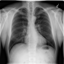

In [ ]:
# View the first item
normal_array[0]

In [ ]:
# Apply the same transformation for the data in effusion.zip file
imagenes = []
with zipfile.ZipFile("effusion.zip") as z:
  for filename in z.namelist():
    if filename.endswith(".png"):
      with z.open(filename) as file:
        img_gray  = Image.open(file).convert("L")  # Transform the image to grayscale
        img_64_64 = img_gray.resize((64, 64))      # Resize to 64 x 64
        img_array = np.array(img_64_64)
        imagenes.append(img_array)

# Convert list of image arrays to a single NumPy array
effusion_array = np.array(imagenes)

In [ ]:
# View dimensions and data type
effusion_array.shape, type(effusion_array)

((350, 64, 64), numpy.ndarray)

array([[  4,   5,   5, ...,  17,   8,  13],
       [ 13,  19,  25, ...,  24,  16,   6],
       [ 50,  68,  73, ...,  15,  24,  18],
       ...,
       [ 86, 128, 155, ...,  35,   7,  15],
       [ 89, 136, 165, ...,  39,   8,  16],
       [ 89, 138, 163, ...,  43,   9,  15]], dtype=uint8)
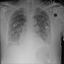

In [ ]:
# View the first item
effusion_array[0]

Finally we can save the data in `effusion_array` and `normal_array` in `.npy` files for later use without having to do the transformations made in this section again.

In [ ]:
# Save transformed data in .npy files
np.save("normal.npy", normal_array)
np.save("efussion.npy", effusion_array)

---

## Data preparation
In this section, we will carry out the following tasks:

1. Create X, the dataset that contains both normal and effusion radiographs.
2. Create y, the dataset that contains the truth labels.
3. View some x-rays of the X and y datasets.
4. Normalize X using min-max.
5. Resize datasets to 4 dimensions
6. Split X and y into test/train datasets.

### 1. Create dataset `X`

In [ ]:
# Load transformed datasets
normal    = np.load("normal.npy")
effusion  = np.load("efussion.npy")

In [ ]:
# Get the size of the datasets
print(f"Tamaño dataset normal:{normal.shape}\nTamaño dataset effusion:{effusion.shape}")

Tamaño dataset normal:(350, 64, 64)
Tamaño dataset effusion:(350, 64, 64)


In [ ]:
# Create dataset
X = np.concatenate((normal, effusion), axis=0) # axis = 0 indicates that the union is done consecutively to obtain 700 x-rays

# Check the size of X
print(X.shape)

(700, 64, 64)


array([[  4,   5,   5, ...,  17,   8,  13],
       [ 13,  19,  25, ...,  24,  16,   6],
       [ 50,  68,  73, ...,  15,  24,  18],
       ...,
       [ 86, 128, 155, ...,  35,   7,  15],
       [ 89, 136, 165, ...,  39,   8,  16],
       [ 89, 138, 163, ...,  43,   9,  15]], dtype=uint8)
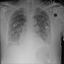

In [ ]:
# Checkbar viewing image 150
X[350]

array([[  4,   5,   5, ...,  17,   8,  13],
       [ 13,  19,  25, ...,  24,  16,   6],
       [ 50,  68,  73, ...,  15,  24,  18],
       ...,
       [ 86, 128, 155, ...,  35,   7,  15],
       [ 89, 136, 165, ...,  39,   8,  16],
       [ 89, 138, 163, ...,  43,   9,  15]], dtype=uint8)
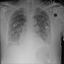

In [ ]:
# Compare to image 0 of the effusion dataset
# It is concluded that the concatenation was successful since they are the same images
effusion[0]

### 2. Create the dataset `y`

In [ ]:
# Create the dataset and
# Define two arrays, one of zeros and one of ones for the positive class
y_normal   = np.zeros((350,))
y_effusion = np.ones((350,))

# Check dimensions
print(y_normal.shape, y_effusion.shape)

(350,) (350,)


In [ ]:
# Concatenate y_normal and y_effusion to form the labels dataset "y"
y = np.concatenate((y_normal, y_effusion), axis=0)

# Check dimensions
print(y.shape)

(700,)


In [ ]:
# Show final dimensions of datasets X and y
print('Dimensiones X:' + str(X.shape))
print('Dimensiones y:' + str(y.shape))

Dimensiones X:(700, 64, 64)
Dimensiones y:(700,)


In [ ]:
int(y[5])

0

### 3. View some x-rays of the `X` and `y` datasets

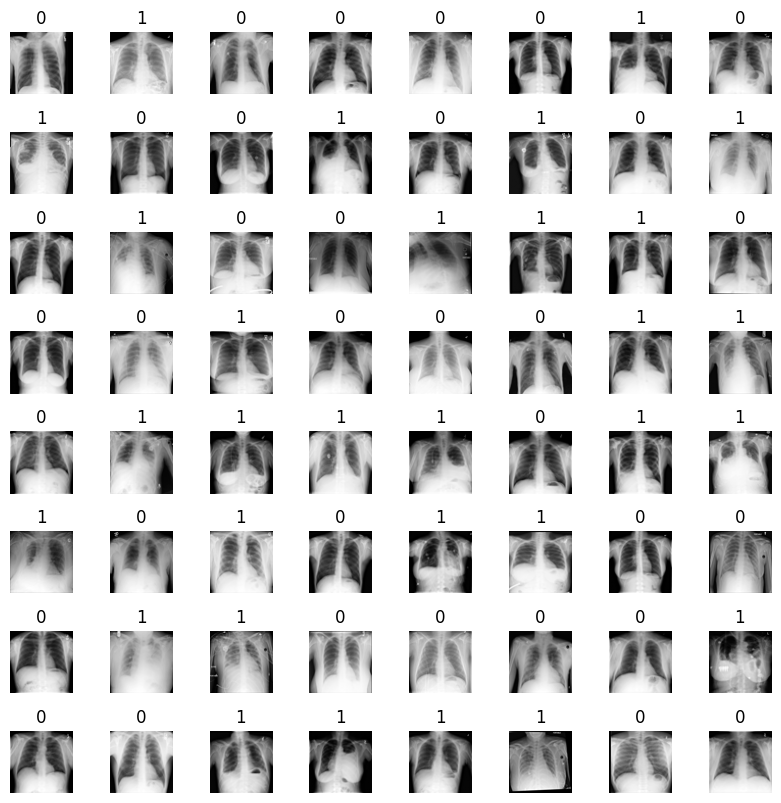

In [ ]:
# View some elements of the X dataset
fig, axes = plt.subplots(nrows= 8, ncols= 8, figsize=(8,8))
fig.tight_layout(pad=0.1)

m,n,p = X.shape
np.random.seed(42)

for i,ax in enumerate(axes.flat):
  # Select a random number
  rand_num = np.random.randint(m)

  # Plot the randomly assigned radiograph
  ax.imshow(X[rand_num], cmap='gray')

  # View your label
  ax.set_title(int(y[rand_num]))
  ax.set_axis_off()

### 4. Normalize `X` using min-max
We will apply a normalization to the data so that the pixel values ​​are in the range (0,1), a range suitable for input to CNNs.


In [ ]:
# Find the minimum and maximum in X
X_min = np.min(X)
X_max = np.max(X)
print(X_min, X_max)

0 255


In [ ]:
# Standardization
X_norm = (X - X_min) / (X_max - X_min)

In [ ]:
# Finding the minimum and maximum in X_norm
X_norm_min = np.min(X_norm)
X_norm_max = np.max(X_norm)
print(X_norm_min, X_norm_max)

0.0 1.0


In [ ]:
# Display the 1st element of X_norm
print(X_norm[0])

[[0.34509804 0.16862745 0.14509804 ... 0.49411765 0.54117647 0.67843137]
 [0.         0.         0.         ... 0.00392157 0.01176471 0.09803922]
 [0.01176471 0.00784314 0.00784314 ... 0.         0.         0.        ]
 ...
 [0.02745098 0.02745098 0.02745098 ... 0.01960784 0.01176471 0.08235294]
 [0.02745098 0.02745098 0.02745098 ... 0.01960784 0.01176471 0.09019608]
 [0.02745098 0.02745098 0.02745098 ... 0.01960784 0.01176471 0.10196078]]


### Resize to 4 dimensions
The following fragment extracted from the `CNN_MNIST.ipynb` notebook located in the [Machine Learning Bioinformatics de la UOC](https://gitlab.uoclabs.uoc.es/machinelearningbioinformatics/machine-learning-bioinformatics/-/blob/master/5_NeuralNetworks/CNN_MNIST.ipynb?ref_type=heads) repository, explains why it is important to do this 4-dimensional resizing of the data that will be used by the CNN networks.

"We do this because a convolutional network expects at its input a 4-dimensional tensor of shape (𝐵, 𝑊, 𝐻, 𝐶), where 𝐵 is the batch size, 𝑊 and 𝐻 are respectively the width and height of our images, and 𝐶 is the number of channels in the images (𝐶=1 for grayscale images, 𝐶=3 for RGB color images, etc.).

Therefore, we want our data to be in the format (700, 64, 64, 1)."

In [ ]:
# Refit to 4 dimensions X_norm
X_reshaped = X_norm.reshape(700,64,64,1)

print(f"Dimensión de X: {X_reshaped.shape}")

Dimensión de X: (700, 64, 64, 1)


### 6. Split `X` and `y` into test/train datasets
In this section we will generate the `train` and `test` datasets by dividing the `X` and `y` datasets in a balanced way.

In [ ]:
# Distribute: 600 for train, 100 for test
# Stratify according to "and" to balance classes
X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, y,
    train_size=600,
    test_size=100,
    stratify=y,
    random_state=42  # for reproducibility
)

In [ ]:
# View dataset dimensions
print(f"Dimensión de X_train: {X_train.shape}\n"
      f"Dimensión de X_test: {X_test.shape}\n"
      f"Dimensión de y_train: {y_train.shape}\n"
      f"Dimensión de y_test: {y_test.shape}\n"
)

Dimensión de X_train: (600, 64, 64, 1)
Dimensión de X_test: (100, 64, 64, 1)
Dimensión de y_train: (600,)
Dimensión de y_test: (100,)



In [ ]:
# Verify that "y_test" has been properly balanced
categoria, cuentas = np.unique(y_test, return_counts = True)
print(categoria, cuentas)

[0. 1.] [50 50]


In [ ]:
# Verify that "y_train" has been properly balanced
categoria, cuentas = np.unique(y_train, return_counts = True)
print(categoria, cuentas)

[0. 1.] [300 300]


---

## Model 1 - CNN
The architecture for the first model that I propose is inspired by LeNet-5, the best-known architecture for CNNs. The following table (extracted from *Géron, A. (2017). Hands-on machine learning with Scikit-Learn and TensorFlow: Concepts, tools, and techniques to build intelligent systems. O’Reilly Media. Page 366*) shows a summary of this architecture.

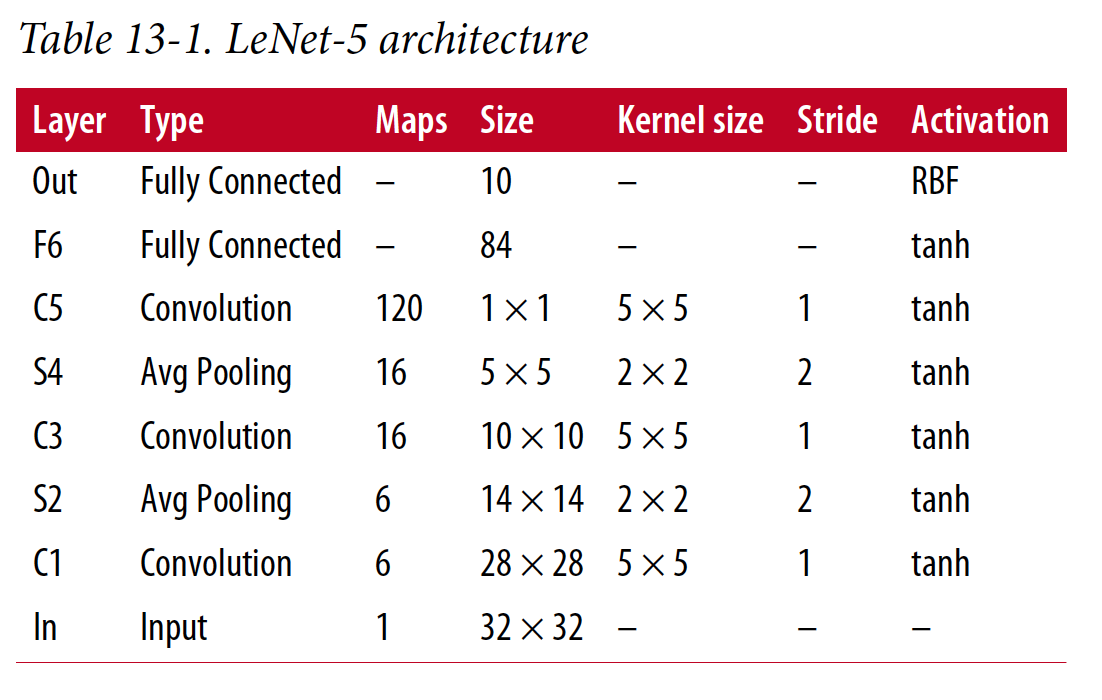

In [ ]:
Image("LeNet-5_architecture.png",width=600, height=400)

### Defining the model architecture
The original architecture was designed for 32×32 images, so it cannot be used directly. Therefore, we will make several adaptations to train the model on 64×64 radiographic images, as shown in the table below.

Additionally, we will define each layer of the model in separate cells. This will help us avoid errors when building the architecture.


| LayerType | Maps / Units | Size (H×W) | Kernel Size | Stride | Padding | Activation |
|-------------------|--------------|------------|--------------|--------|---------|-------------|
| Input | 1 (grayscale)| 64×64 | – | – | – | – |
| Conv2D | 32 | 62 × 62 | 3×3 | 1 | Valid | ReLU |
| MaxPooling2D | 32 | 31 × 31 | 2×2 | 2 | Valid | – |
| Conv2D | 64 | 29 × 29 | 3×3 | 1 | Valid | ReLU |
| MaxPooling2D | 64 | 14×14 | 2×2 | 2 | Valid | – |
| Conv2D | 128 | 12×12 | 3×3 | 1 | Valid | ReLU |
| MaxPooling2D | 128 | 6×6 | 2×2 | 2 | Valid | – |
| Conv2D | 128 | 4×4 | 3×3 | 1 | Valid | ReLU |
| MaxPooling2D | 128 | 2×2 | 2×2 | 2 | Valid | – |
| Flatten | – | 512 | – | – | – | – |
| Dense | 128 | – | – | – | – | ReLU |
| Dropout | – | – | – | – | – | – |
| Dense | 32 | – | – | – | – | ReLU |
| Dense | 1 | – | – | – | – | Sigmoid |


In [ ]:
# Define 1st CNN model sequentially
model = Sequential()

In [ ]:
# Define dimensions of the input data
model.add(Input(shape=(64, 64, 1)))

In [ ]:
# Define 1st convolutional layer
model.add(Conv2D(
    filters=32,
    kernel_size=(3,3),
    activation='relu')
)

In [ ]:
# Define 1st pooling layer
model.add(MaxPooling2D((2,2)))

In [ ]:
# Define 2nd convolutional layer
model.add(Conv2D(
    filters=64,
    kernel_size=(3,3),
    activation='relu')
)

In [ ]:
# Define 2nd pooling layer
model.add(MaxPooling2D((2,2)))

In [ ]:
# Define 3rd convolutional layer
model.add(Conv2D(
    filters=128,
    kernel_size=(3,3),
    activation='relu')
)

In [ ]:
# Define 3rd pooling layer
model.add(MaxPooling2D((2,2)))

In [ ]:
# Define 4th convolutional layer
model.add(Conv2D(
    filters=128,
    kernel_size=(3,3),
    activation='relu')
)

In [ ]:
# Define 4th layer of pooling
model.add(MaxPooling2D((2,2)))

In [ ]:
# Convert a multidimensional tensor to a one-dimensional vector
model.add(Flatten())

In [ ]:
# Include a dropout layer to regularize the behavior of the model
# model.add(Dropout(0.5))

In [ ]:
# Define 1st fully connected layer
model.add(Dense(128, activation='relu'))

# Define 2nd fully connected layer
model.add(Dense(32, activation='relu'))

In [ ]:
# Define output layer
model.add(Dense(1, activation='sigmoid'))

In [ ]:
# View model details
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 310,081 (1.18 MB)

 Trainable params: 310,081 (1.18 MB)

 Non-trainable params: 0 (0.00 B)

### Model compilation

In [ ]:
# Establish regularization, a cost function and performance metrics
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',   # Loss function for binary classification
    metrics=['accuracy']          # Precision Metric
)

### Model training

In [ ]:
# Define epochs, batch size and train the model
n_epochs = 10
n_batch  = 128

mfit = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    batch_size=n_batch,
    epochs=n_epochs
    )

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 866ms/step - accuracy: 0.5083 - loss: 0.6915 - val_accuracy: 0.7200 - val_loss: 0.6761
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.6552 - loss: 0.6714 - val_accuracy: 0.5100 - val_loss: 0.6823
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 801ms/step - accuracy: 0.6035 - loss: 0.6458 - val_accuracy: 0.7400 - val_loss: 0.5782
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.6947 - loss: 0.5933 - val_accuracy: 0.6600 - val_loss: 0.5853
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 777ms/step - accuracy: 0.6374 - loss: 0.6175 - val_accuracy: 0.6900 - val_loss: 0.5861
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.6664 - loss: 0.5893 - val_accuracy: 0.7500 - val_loss: 0.5179
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 782ms/step - accuracy: 0.7316 - loss: 0.5476 - val_accuracy: 0.8000 - val_loss: 0.5208
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 997ms/step - accuracy: 0.7436 - loss: 0.5363 - val_accuracy: 0.7900 - val_loss: 0.4914
E

### Representation of accuracy and loss function at each epoch
The code presented below has been taken from the notebook `CNN_MNIST.ipynb` located in the [Machine Learning Bioinformatics de la UOC](https://gitlab.uoclabs.uoc.es/machinelearningbioinformatics/machine-learning-bioinformatics/-/blob/master/5_NeuralNetworks/CNN_MNIST.ipynb?ref_type=heads) repository


In [ ]:
# Plot accuracy and loss of 1st CNN model
def plot_prediction(n_epochs, mfit):
    N = n_epochs
    plt.style.use("ggplot")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,6))
    fig.suptitle('Training Loss and Accuracy')

    ax1.plot(np.arange(0, N), mfit.history["accuracy"], label="train")
    ax1.plot(np.arange(0, N), mfit.history["val_accuracy"], label="val")
    ax1.set_title("Accuracy")
    ax1.set_xlabel("Epoch No.")
    ax1.set_ylabel("Accuracy")
    ax1.legend(loc="lower right")

    ax2.plot(np.arange(0, N), mfit.history["loss"], label="train")
    ax2.plot(np.arange(0, N), mfit.history["val_loss"], label="val")
    ax2.set_title("Loss")
    ax2.set_xlabel("Epoch No.")
    ax2.set_ylabel("Loss")
    ax2.legend(loc="upper right")

    plt.show()

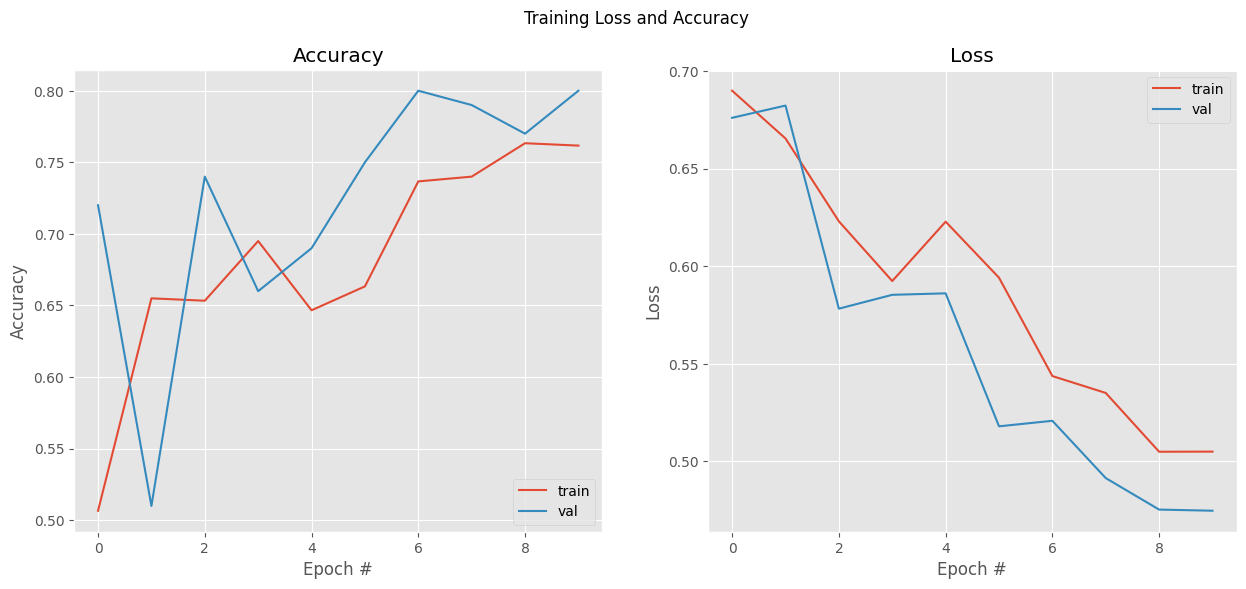

In [ ]:
# Plot accuracy and loss of 1st CNN model
plot_prediction(n_epochs, mfit)

### Predictions with the model

In [ ]:
# Get x-ray predictions in X_test
predicciones = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


In [ ]:
# Classify predictions into two categories normal and spill
y_pred = (predicciones >= 0.5).astype(int)

In [ ]:
# Check the dimensions of y_test and y_hat
print(y_test.shape, y_pred.shape)

(100,) (100, 1)


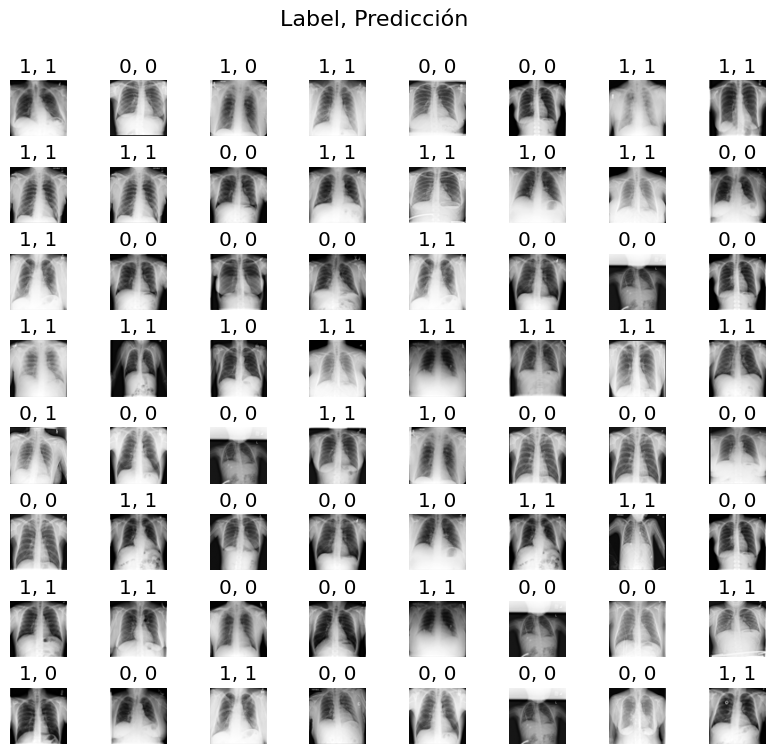

In [ ]:
# View some predictions and their respective x-rays
fig, axes = plt.subplots(nrows= 8, ncols= 8, figsize=(8,8))
fig.tight_layout(pad=0.1, rect=[0, 0.03, 1, 0.9])

m,n,p,q = X_test.shape
np.random.seed(42)

for i,ax in enumerate(axes.flat):
  # Select a random number
  rand_num = np.random.randint(m)

  # Plot the randomly assigned radiograph
  ax.imshow(X[rand_num], cmap='gray')

  # View your label
  ax.set_title(f"{int(y_test[rand_num])}, {int(y_pred[rand_num][0])}")
  ax.set_axis_off()

fig.suptitle("Label, Predicción", fontsize=16)
plt.show()

### Model evaluation

We will calculate the following metrics taking into account that the positive class is x-rays with effusion:  

- Number of FPs
- Number of FNs
- Classification error
- AUC value

For the first two metrics, we will use a [confusion matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html#confusion-matrix). We will then calculate the [accuracy](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html#accuracy-score) parameter to determine the classification error `1 - accuracy`. And finally we will use the `sklearn.metrics` library to determine AUC.

In [ ]:
# Obtain the confusion matrix
# Use ravel() to convert a multidimensional array to a one-dimensional array
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# Calculate classification error
error = 1 - accuracy_score(y_test, y_pred)

# View metrics
print(f"Para y_test con n = {len(y_test)} se obtuvieron:\n"
      f"Verdaderos Positivos:   {tn}\n"
      f"Falsos Positivos:       {fp}\n"
      f"Falsos Negativos:       {fn}\n"
      f"Verdaderos Positivos:   {tp}\n"
      f"Error de clasificación: {error:.4f}")

Para y_test con n = 100 se obtuvieron:
Verdaderos Positivos:   45
Falsos Positivos:       5
Falsos Negativos:       15
Verdaderos Positivos:   35
Error de clasificación: 0.2000


In [ ]:
# Check y_test dimensions and predictions
print(y_test.shape, predicciones[:,0].shape)

(100,) (100,)


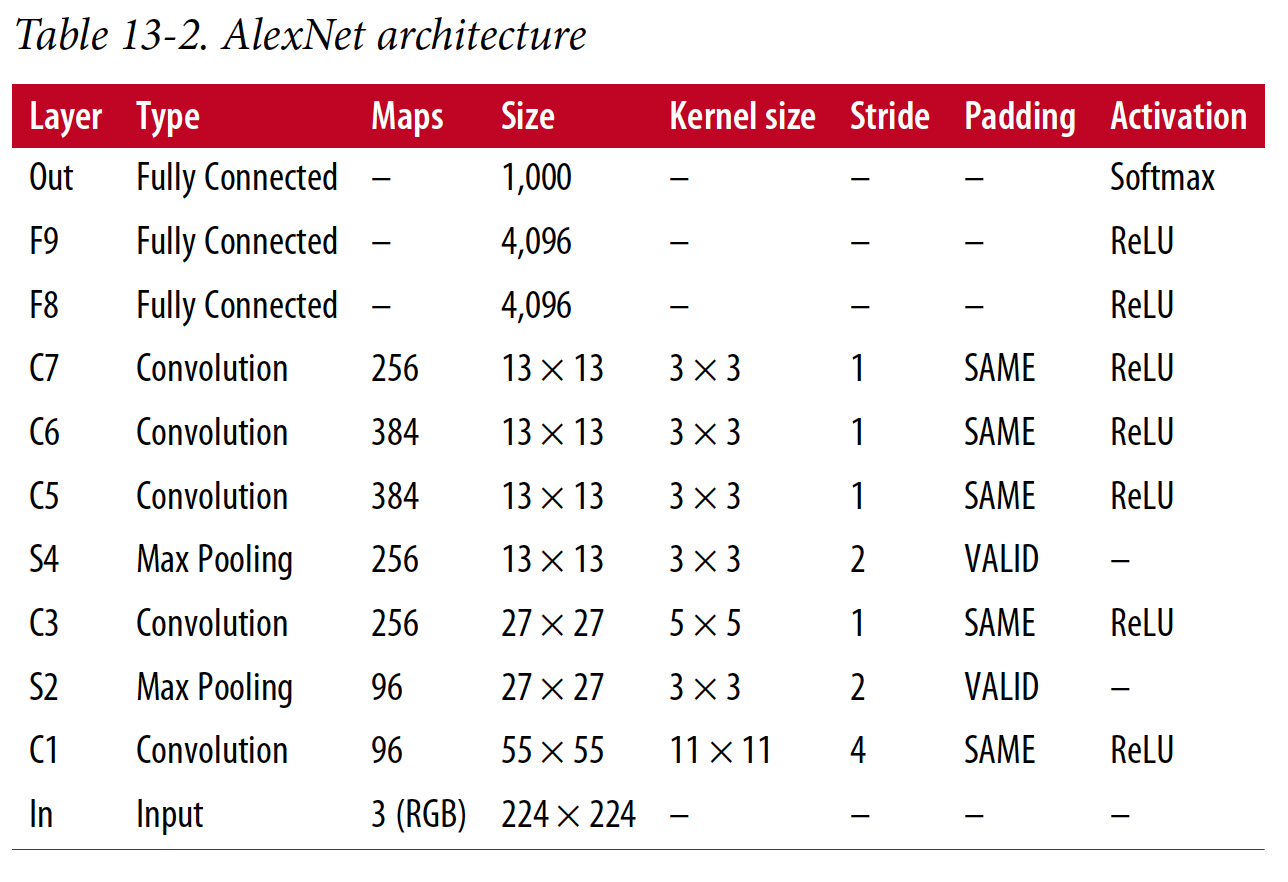

In [ ]:
Image("AlexNet_architecture.png",width=600, height=400)

In [ ]:
# Calculate ROC curve and AUC
fpr, tpr, thresholds  = roc_curve(y_test, predicciones[:,0])      # We obtain FPs and TPs rates
auc_score             = roc_auc_score(y_test, predicciones[:,0])

print(f"AUC: {auc_score:.4f}")

AUC: 0.8776


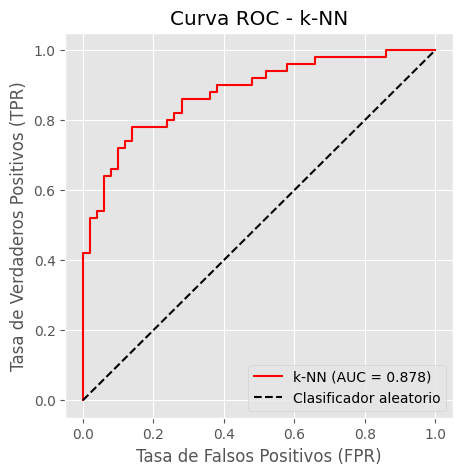

In [ ]:
# Plot ROC curve
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f'k-NN (AUC = {auc_score:.3f})', color='red')
plt.plot([0, 1], [0, 1], 'k--', label='Clasificador aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - k-NN')
plt.legend()
plt.show()

In [ ]:
# Create a metrics dataframe
metricas_modelo1    = [[tn, fp, fn, tp, error, fpr, tpr, thresholds, auc_score]]
df_metricas_modelo1 = pd.DataFrame(metricas_modelo1,
                                   columns=["TN", "FP", "FN", "TP", "Error", "FPR", "TPR", "Thresholds", "AUC"])
# View metrics
df_metricas_modelo1

,TN,FP,FN,TP,Error,FPR,TPR,Thresholds,AUC
0,45,5,15,35,0.2,"[0.0, 0.0, 0.0, 0.02, 0.02, 0.04, 0.04, 0.06, ...","[0.0, 0.02, 0.42, 0.42, 0.52, 0.52, 0.54, 0.54...","[inf, 0.95441824, 0.7143521, 0.7000786, 0.6799...",0.8776


---

## Model 2 - CNN
The architecture for the second model that I propose is inspired by AlexNet, an architecture that in 2012 won the ImageNet ILSVR challenge developed by Alex Krizhevsky. The following table (extracted from *Géron, A. (2017). Hands-on machine learning with Scikit-Learn and TensorFlow: Concepts, tools, and techniques to build intelligent systems. O’Reilly Media. Page 367*) shows a summary of said architecture.

### CNN's architecture 
The architecture cannot be used as is since it was implemented for 224 x 224 images, so some adaptations will be made to train the model with 64 x 64 radiographic images. As shown in the following table:

| LayerType | Maps / Units | Size (H×W) | Kernel Size | Stride | Padding | Activation |
|-------------------|--------------|------------|--------------|--------|---------|-------------|
| Input | 1 (grayscale)| 64×64 | – | – | – | – |
| Conv2D | 64 | 32×32 | 7×7 | 2 | Same | ReLU |
| MaxPooling2D | 64 | 16×16 | 2×2 | 2 | Valid | – |
| Conv2D | 128 | 16×16 | 5×5 | 1 | Same | ReLU |
| MaxPooling2D | 128 | 8×8 | 2×2 | 2 | Valid | – |
| Conv2D | 256 | 8×8 | 3×3 | 1 | Same | ReLU |
| Conv2D | 256 | 8×8 | 3×3 | 1 | Same | ReLU |
| Conv2D | 128 | 8×8 | 3×3 | 1 | Same | ReLU |
| MaxPooling2D | 128 | 4×4 | 2×2 | 2 | Valid | – |
| Flatten | – | 2048 | – | – | – | – |
| Dense | 128 | – | – | – | – | ReLU |
| Dense | 32 | – | – | – | – | ReLU |
| Dense | 1 | – | – | – | – | Sigmoid |


In [ ]:
# Define architecture 2nd. CNN model based on AlexNet sequentially
model = Sequential()

# Define dimensions of the input data
model.add(Input(shape=(64, 64, 1)))

# Define 1st, convolutional and pooling layer
model.add(Conv2D(64, kernel_size=7, strides=2, activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=2, strides=2))

# Define 2nd. convolutional and pooling layer
model.add(Conv2D(128, kernel_size=5, strides=1, activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=2, strides=2))

# Define 3rd. convolutional layer
model.add(Conv2D(256, kernel_size=3, activation='relu', padding='same'))

# Define 4th. convolutional layer
model.add(Conv2D(256, kernel_size=3, activation='relu', padding='same'))

# Define 5th. convolutional and pooling layer
model.add(Conv2D(128, kernel_size=3, activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=2, strides=2))

# Convert a multidimensional tensor to a one-dimensional vector
model.add(Flatten())

# Define 1st. fully connected layer
model.add(Dense(128, activation='relu'))

# Define 2nd. fully connected layer
model.add(Dense(32, activation='relu'))

# Define output layer
model.add(Dense(1, activation='sigmoid'))

# View model details
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │         3,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,654,849 (6.31 MB)

 Trainable params: 1,654,849 (6.31 MB)

 Non-trainable params: 0 (0.00 B)

### Model compilation

In [ ]:
# Establish regularization, a cost function and performance metrics
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',   # Loss function for binary classification
    metrics=['accuracy']          # Precision Metric
)

### Model training

In [ ]:
# Define epochs, batch size and train the model
n_epochs = 10
n_batch  = 128

mfit = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    batch_size=n_batch,
    epochs=n_epochs
    )

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.5095 - loss: 0.6953 - val_accuracy: 0.5100 - val_loss: 0.6924
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.4900 - loss: 0.6924 - val_accuracy: 0.5700 - val_loss: 0.6916
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step - accuracy: 0.5389 - loss: 0.6904 - val_accuracy: 0.5000 - val_loss: 0.6871
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step - accuracy: 0.5325 - loss: 0.6774 - val_accuracy: 0.5100 - val_loss: 0.6777
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 15s 3s/step - accuracy: 0.5248 - loss: 0.6858 - val_accuracy: 0.7800 - val_loss: 0.6843
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.7284 - loss: 0.6742 - val_accuracy: 0.7400 - val_loss: 0.6033
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.7762 - loss: 0.5764 - val_accuracy: 0.7800 - val_loss: 0.4756
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.7658 - loss: 0.4778 - val_accuracy: 0.7500 - val_loss: 0.4733
Epoch 9/

### Representation of accuracy and loss function at each epoch
The code presented below has been taken from the notebook `CNN_MNIST.ipynb` located in the [Machine Learning Bioinformatics de la UOC](https://gitlab.uoclabs.uoc.es/machinelearningbioinformatics/machine-learning-bioinformatics/-/blob/master/5_NeuralNetworks/CNN_MNIST.ipynb?ref_type=heads) repository


In [ ]:
# Plot accuracy and loss
def plot_prediction(n_epochs, mfit):
    N = n_epochs
    plt.style.use("ggplot")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,6))
    fig.suptitle('Training Loss and Accuracy')

    ax1.plot(np.arange(0, N), mfit.history["accuracy"], label="train")
    ax1.plot(np.arange(0, N), mfit.history["val_accuracy"], label="val")
    ax1.set_title("Accuracy")
    ax1.set_xlabel("Epoch No.")
    ax1.set_ylabel("Accuracy")
    ax1.legend(loc="lower right")

    ax2.plot(np.arange(0, N), mfit.history["loss"], label="train")
    ax2.plot(np.arange(0, N), mfit.history["val_loss"], label="val")
    ax2.set_title("Loss")
    ax2.set_xlabel("Epoch No.")
    ax2.set_ylabel("Loss")
    ax2.legend(loc="upper right")

    plt.show()

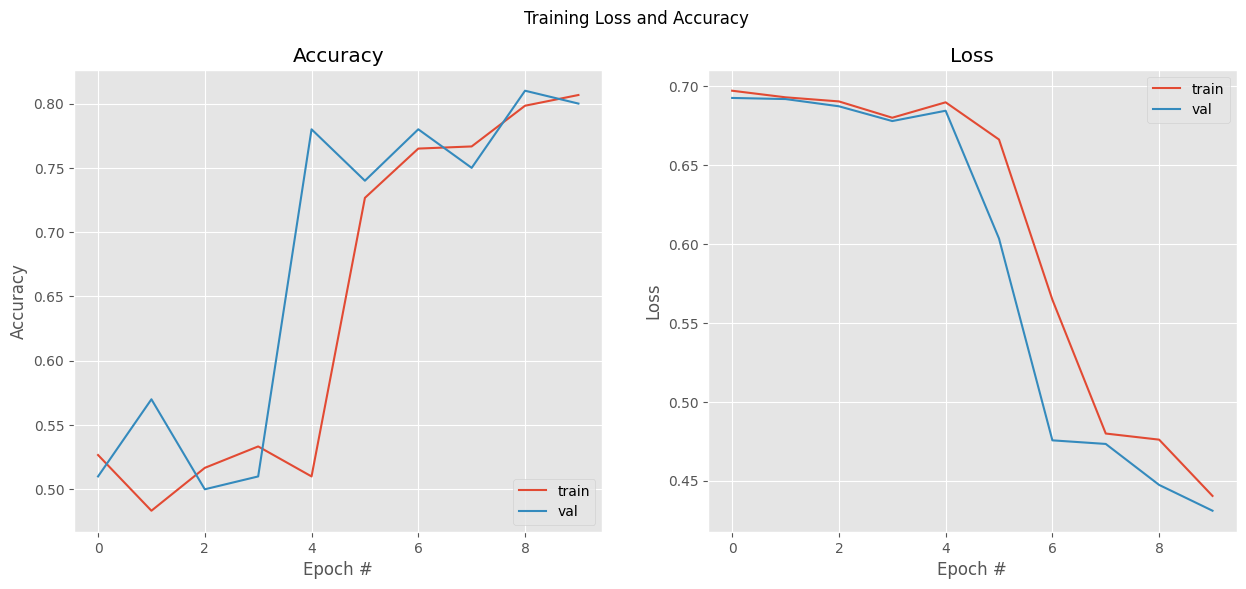

In [ ]:
# Plot accuracy and loss for the 1st CNN model
plot_prediction(n_epochs, mfit)

### Predictions with the model

In [ ]:
# Get x-ray predictions in X_test
predicciones = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 206ms/step


In [ ]:
# Classify predictions into two categories normal and spill
y_pred = (predicciones >= 0.5).astype(int)

In [ ]:
# Check the dimensions of y_test and y_hat
print(y_test.shape, y_pred.shape)

(100,) (100, 1)


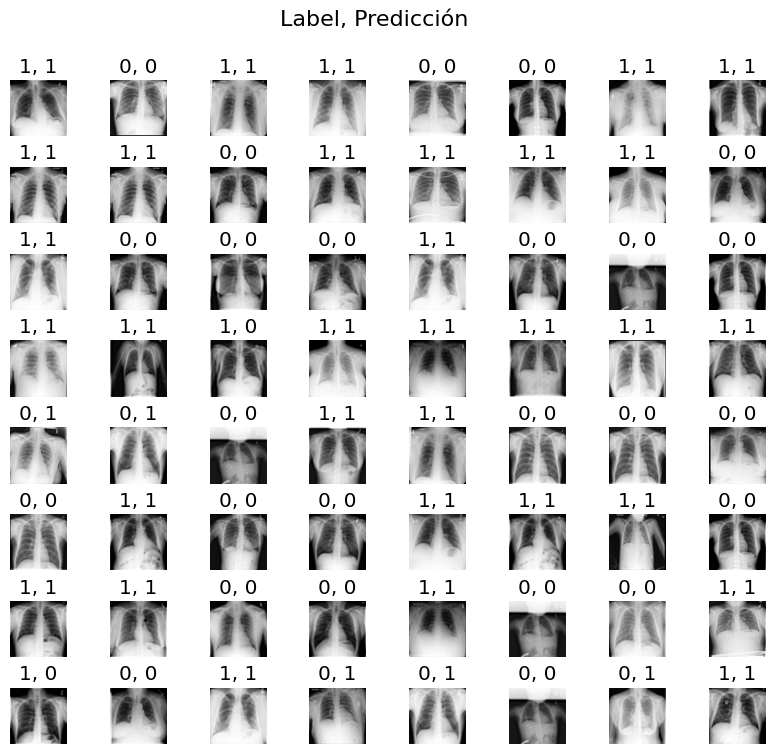

In [ ]:
# View some predictions and their respective x-rays
fig, axes = plt.subplots(nrows= 8, ncols= 8, figsize=(8,8))
fig.tight_layout(pad=0.1, rect=[0, 0.03, 1, 0.9])

m,n,p,q = X_test.shape
np.random.seed(42)

for i,ax in enumerate(axes.flat):
  # Select a random number
  rand_num = np.random.randint(m)

  # Plot the randomly assigned radiograph
  ax.imshow(X[rand_num], cmap='gray')

  # View your label
  ax.set_title(f"{int(y_test[rand_num])}, {int(y_pred[rand_num][0])}")
  ax.set_axis_off()

fig.suptitle("Label, Predicción", fontsize=16)
plt.show()

### Model evaluation

As in Model 1, we will calculate the following metrics taking into account that the positive class is x-rays with effusion:  

- Number of FPs
- Number of FNs
- Classification error
- AUC value

For the first two metrics, we will use a [confusion matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html#confusion-matrix). We will then calculate the [accuracy](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html#accuracy-score) parameter to determine the classification error `1 - accuracy`. And finally we will use the `sklearn.metrics` library to determine AUC.

In [ ]:
# Obtain the confusion matrix
# Use ravel() to convert a multidimensional array to a one-dimensional array
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# Calculate classification error
error = 1 - accuracy_score(y_test, y_pred)

# View metrics
print(f"Para y_test con n = {len(y_test)} se obtuvieron:\n"
      f"Verdaderos Positivos:   {tn}\n"
      f"Falsos Positivos:       {fp}\n"
      f"Falsos Negativos:       {fn}\n"
      f"Verdaderos Positivos:   {tp}\n"
      f"Error de clasificación: {error:.4f}")

Para y_test con n = 100 se obtuvieron:
Verdaderos Positivos:   38
Falsos Positivos:       12
Falsos Negativos:       8
Verdaderos Positivos:   42
Error de clasificación: 0.2000


In [ ]:
# Check y_test dimensions and predictions
print(y_test.shape, predicciones[:,0].shape)

(100,) (100,)


In [ ]:
# Calculate ROC curve and AUC
fpr, tpr, thresholds  = roc_curve(y_test, predicciones[:,0])      # We obtain FPs and TPs rates
auc_score             = roc_auc_score(y_test, predicciones[:,0])

print(f"AUC: {auc_score:.4f}")

AUC: 0.8920


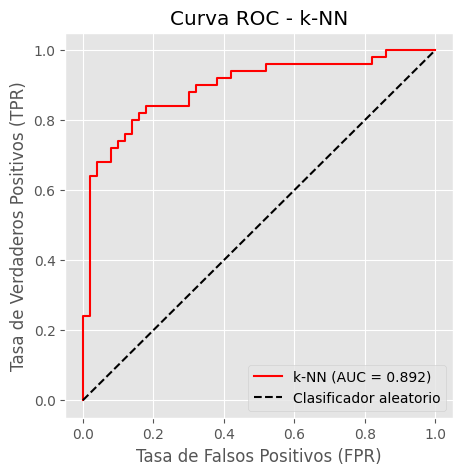

In [ ]:
# Plot ROC curve
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f'k-NN (AUC = {auc_score:.3f})', color='red')
plt.plot([0, 1], [0, 1], 'k--', label='Clasificador aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - k-NN')
plt.legend()
plt.show()

In [ ]:
# Create a metrics dataframe
metricas_modelo2    = [[tn, fp, fn, tp, error, fpr, tpr, thresholds, auc_score]]
df_metricas_modelo2 = pd.DataFrame(metricas_modelo2,
                                   columns=["TN", "FP", "FN", "TP", "Error", "FPR", "TPR", "Thresholds", "AUC"])
# View metrics
df_metricas_modelo2

,TN,FP,FN,TP,Error,FPR,TPR,Thresholds,AUC
0,38,12,8,42,0.2,"[0.0, 0.0, 0.0, 0.02, 0.02, 0.04, 0.04, 0.08, ...","[0.0, 0.02, 0.24, 0.24, 0.64, 0.64, 0.68, 0.68...","[inf, 0.9724216, 0.9056567, 0.90543103, 0.7929...",0.892


---

## Performance comparison of the two CNN models

In [ ]:
# View CNN Model 1 Metrics
df_metricas_modelo1

,TN,FP,FN,TP,Error,FPR,TPR,Thresholds,AUC
0,45,5,15,35,0.2,"[0.0, 0.0, 0.0, 0.02, 0.02, 0.04, 0.04, 0.06, ...","[0.0, 0.02, 0.42, 0.42, 0.52, 0.52, 0.54, 0.54...","[inf, 0.95441824, 0.7143521, 0.7000786, 0.6799...",0.8776


In [ ]:
# View CNN Model 2 Metrics
df_metricas_modelo2

,TN,FP,FN,TP,Error,FPR,TPR,Thresholds,AUC
0,38,12,8,42,0.2,"[0.0, 0.0, 0.0, 0.02, 0.02, 0.04, 0.04, 0.08, ...","[0.0, 0.02, 0.24, 0.24, 0.64, 0.64, 0.68, 0.68...","[inf, 0.9724216, 0.9056567, 0.90543103, 0.7929...",0.892


**Comments on model 1 - CNN**

Model 1 shows more conservative behavior, since it generates fewer false positives. This means fewer false alarms when diagnosing a stroke when there really isn't one.

Its ROC curve is convex and stays clearly away from the random diagonal, indicating that the model distinguishes well between positive and negative cases. Furthermore, the TPR and FPR values ​​advance progressively, without abrupt jumps or flat areas, indicating that the model responds stably and sensitively to changes in thresholds. In terms of AUC, the model achieves an 87.76% probability of assigning a higher score to an x-ray with effusion compared to a normal one, which supports its good performance.

Regarding the learning curve, a constant improvement is observed in both precision and loss. The training accuracy starts at around 50% and reaches approximately 0.74 at epoch 10, while the validation accuracy maintains a similar pattern. The loss also decreases steadily, without notable divergences between the training and validation sets. This suggests that the model generalizes correctly and does not show signs of overfitting or underfitting.

**Comments on model 2 - CNN**

The metrics indicate that model 2 is more sensitive, as it detects a greater number of true positives and makes fewer false negatives. This behavior is preferable in the context of medical radiology, where it is more important to identify all cases with effusion, even if this implies a higher number of false positives.

In general, model 2 performs better than model 1. The ROC curve is convex and clearly away from the diagonal, indicating good discrimination ability. Based on the AUC value (0.892), there is an 89.2% probability that the model assigns a higher probability to an x-ray with effusion than to one without effusion.

Regarding the learning curve, model 2 shows good generalization capacity. The training and validation accuracy remains aligned and increasing, reaching approximately 0.80 at epoch 10. On the other hand, the loss in the training and validation sets decreases consistently, dropping to a value of 0.44 at the end of training.
